# 04. Stress Benchmark across Candidate Models

## Goal

This notebook upgrades the previous model-comparison stage into a **standardized stress benchmark** across all candidate models.

The key question is no longer only *which model is best on a clean benchmark*, but:

- which model remains reliable under realistic stress,
- which failure modes are most damaging,
- and how clean accuracy should be balanced against robustness.

Compared with the earlier single-model stress notebook, this stage is more systematic:
all candidate models are exposed to the **same stress protocol**, then ranked under a **joint clean-accuracy / robustness criterion**.

## Notebook Roadmap

1. Load processed training data and candidate models  
2. Define a standardized stress protocol  
3. Run clean hold-out evaluation for all models  
4. Run all-model stress benchmark  
5. Summarize failure modes by stress family  
6. Build a **clean-first but robustness-aware** joint ranking  
7. Select the champion model for the intervention stage

## Input Data

This notebook uses the processed housing dataset generated in the feature-engineering stage.

The target variable is `SalePrice_log`, and the same train/validation split is used for all candidate models to keep the stress benchmark fair.

Unlike the original stress notebook, this stage does **not** start from a preselected Gradient Boosting model.  
Instead, model choice itself becomes part of the robustness question.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

for p in [PROJECT_ROOT, SRC_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR = PROJECT_ROOT / "results" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

from model import get_models
from stress_utils import make_train_valid_split
from stress_protocol import run_clean_benchmark, run_all_models_stress_suite
from robust_score import build_robust_summary

In [2]:
train_processed = pd.read_csv(DATA_DIR / "train_processed.csv")

X = train_processed.drop("SalePrice_log", axis=1)
y = train_processed["SalePrice_log"]

X_train, X_valid, y_train, y_valid = make_train_valid_split(
    X, y, test_size=0.2, random_state=42
)

models = get_models(random_state=42)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("Number of candidate models:", len(models))
print("Candidates:", list(models.keys()))

X_train shape: (1160, 275)
X_valid shape: (291, 275)
Number of candidate models: 7
Candidates: ['Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost']


## 1. Stress Protocol Design

To keep the comparison fair, every candidate model is evaluated under the same four axes:

1. **clean hold-out accuracy**  
2. **feature noise**: mild numeric perturbation at test time  
3. **feature ablation**: retraining after removing important feature groups  
4. **target corruption**: training on mildly corrupted regression targets  
5. **subgroup reliability**: performance disparity across low / mid / high price groups

This protocol is intentionally simple and interpretable.
The goal here is not to simulate every possible failure mode, but to build a **clear and reusable robustness benchmark** for tabular house-price prediction.

In [3]:
noise_cols = [
    c for c in ["GrLivArea", "TotalSF", "LotArea", "HouseAge", "TotalBath"]
    if c in X_valid.columns
]

feature_groups = {
    "Garage": ["Garage"],
    "Basement": ["Bsmt", "Basement"],
    "PorchDeck": ["Porch", "Deck"],
}

noise_scales = (0.03, 0.05)
target_scales = (0.03,)
target_frac = 0.15

print("noise_cols:", noise_cols)
print("feature_groups:", feature_groups)

noise_cols: ['GrLivArea', 'TotalSF', 'LotArea', 'HouseAge', 'TotalBath']
feature_groups: {'Garage': ['Garage'], 'Basement': ['Bsmt', 'Basement'], 'PorchDeck': ['Porch', 'Deck']}


## 2. Clean Hold-out Benchmark

I first run a simple clean hold-out comparison before introducing any stress.

This step is important because the stress benchmark should not erase the original predictive objective:
house-price prediction is still a supervised regression task, so clean performance remains the primary anchor.

In [4]:
clean_holdout_df, fitted_models = run_clean_benchmark(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
)

clean_holdout_df = (
    clean_holdout_df[["model", "rmse", "mae", "r2"]]
    .rename(columns={"rmse": "clean_rmse", "mae": "clean_mae", "r2": "clean_r2"})
    .sort_values("clean_rmse")
    .reset_index(drop=True)
)

clean_holdout_df.to_csv(TABLE_DIR / "stress_benchmark_clean_holdout.csv", index=False)
clean_holdout_df

,model,clean_rmse,clean_mae,clean_r2
0,GradientBoosting,0.110588,0.074016,0.918985
1,ElasticNet,0.114178,0.076801,0.913639
2,XGBoost,0.114301,0.078064,0.913453
3,Lasso,0.114350,0.076972,0.913378
4,LightGBM,0.116992,0.079272,0.909330
5,Ridge,0.121692,0.083595,0.901898
6,RandomForest,0.138283,0.091824,0.873325


### Interpretation Angle

In the current run, **GradientBoosting** gives the best clean hold-out RMSE, while **Ridge** is clearly less accurate on the original task.

This matters for the later ranking step.
A robustness benchmark should not accidentally reward a model that is extremely conservative but too weak on the clean prediction objective.
That is why the final joint ranking below will be **clean-first but robustness-aware**, rather than robustness-only.

## 3. Run the All-Model Stress Benchmark

Next, I expose every candidate model to the same stress protocol and collect:

- long-format stress results,
- subgroup-level reliability results,
- and a family-level summary of average degradation.

In [5]:
stress_long_df, subgroup_long_df = run_all_models_stress_suite(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    noise_cols=noise_cols,
    feature_groups=feature_groups,
    noise_scales=noise_scales,
    target_scales=target_scales,
    target_frac=target_frac,
    random_state=42,
)

family_summary_df = (
    stress_long_df.groupby(["model", "stress_family"], as_index=False)
    .agg(
        mean_delta_rmse=("delta_rmse", "mean"),
        mean_delta_mae=("delta_mae", "mean"),
        mean_delta_r2=("delta_r2", "mean"),
    )
)

stress_long_df.to_csv(TABLE_DIR / "stress_benchmark_long.csv", index=False)
subgroup_long_df.to_csv(TABLE_DIR / "stress_benchmark_subgroup_long.csv", index=False)
family_summary_df.to_csv(TABLE_DIR / "stress_benchmark_family_summary.csv", index=False)

print("stress_long_df shape:", stress_long_df.shape)
print("subgroup_long_df shape:", subgroup_long_df.shape)
family_summary_df.head()

stress_long_df shape: (49, 12)
subgroup_long_df shape: (21, 8)


,model,stress_family,mean_delta_rmse,mean_delta_mae,mean_delta_r2
0,ElasticNet,feature_ablation,0.001282,0.000886,-0.001951
1,ElasticNet,feature_noise,0.000114,0.000085,-0.000172
2,ElasticNet,target_corruption,-0.000001,0.000076,0.000001
3,GradientBoosting,feature_ablation,0.001818,0.001811,-0.002697
4,GradientBoosting,feature_noise,0.000015,0.000123,-0.000022


## 4. Average RMSE Degradation by Stress Family

This chart aggregates the mean RMSE change within each stress family.

Positive values indicate degradation; negative values mean that the stressed setting happened to produce a slightly lower RMSE in that run.
Those small negative values should be interpreted cautiously: they usually reflect randomness, re-training effects, or mild regularization side-effects, not true “improvement under damage”.

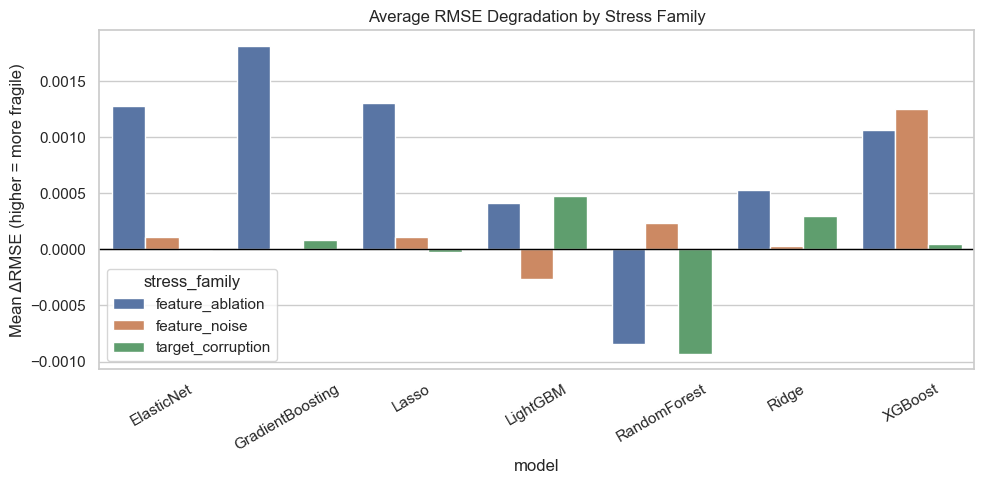

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=family_summary_df, x="model", y="mean_delta_rmse", hue="stress_family")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average RMSE Degradation by Stress Family")
plt.ylabel("Mean ΔRMSE (higher = more fragile)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "stress_benchmark_family_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation Angle

The current benchmark suggests three clear patterns.

1. **Feature ablation is the most damaging stress family for most models.**  
   In other words, removing information blocks hurts more than adding mild numeric noise.

2. **GradientBoosting is very stable to small feature noise**, while still remaining competitive under the other stress families.  
   This makes it a strong candidate for the intervention stage.

3. **Ridge is the most robust overall**, but this robustness comes with a noticeable clean-performance cost.  
   That makes it useful as a robustness reference model, but not automatically the best final choice for this project.

## 5. Subgroup Reliability

Average performance can hide uneven behavior across different parts of the market.

Here I summarize subgroup robustness through the **worst price-group gap**:
the difference between the model's worst subgroup RMSE and its overall clean RMSE.
Lower is better.

In [7]:
subgroup_gap_df = (
    subgroup_long_df.groupby("model", as_index=False)
    .agg(
        worst_group_gap=("rmse_gap_vs_overall", "max"),
        worst_group_rmse=("rmse", "max"),
    )
    .sort_values("worst_group_gap")
    .reset_index(drop=True)
)

subgroup_gap_df

,model,worst_group_gap,worst_group_rmse
0,Ridge,0.033156,0.154848
1,GradientBoosting,0.039096,0.149683
2,LightGBM,0.040186,0.157178
3,XGBoost,0.041117,0.155419
4,ElasticNet,0.041811,0.155989
5,Lasso,0.042089,0.156440
6,RandomForest,0.048970,0.187253


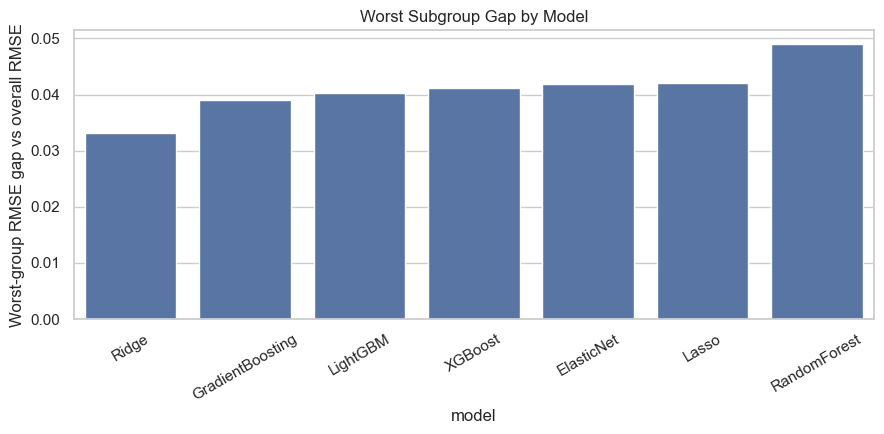

In [8]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=subgroup_gap_df, x="model", y="worst_group_gap")
plt.title("Worst Subgroup Gap by Model")
plt.ylabel("Worst-group RMSE gap vs overall RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "stress_benchmark_worst_group_gap.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation Angle

The low-price segment remains the hardest subgroup across models, and **Ridge** shows the smallest worst-group gap.

However, **GradientBoosting is close behind on subgroup reliability**, while preserving much stronger clean accuracy.
This again supports a clean-first ranking strategy instead of selecting the purely most stable linear model.

## 6. Joint Ranking under Clean Accuracy and Stress Robustness

To select a champion model for the next stage, I combine:

- **clean hold-out RMSE**
- **average degradation under stress**
- **worst subgroup gap**

This produces two related quantities:

- **`RobustScore`**: a robustness-oriented score where higher is better  
- **`joint_rank_score`**: the final decision score where lower is better

The exact weighting is a heuristic design choice, not a universal law.  
Its purpose is to make model selection **explicitly robustness-aware** rather than based only on clean accuracy. 

The final score uses:

- `clean_weight = 1.0`
- `robust_weight = 0.5`


In [13]:
family_weights = {
    "feature_ablation": 0.40,
    "feature_noise": 0.20,
    "target_corruption": 0.15,
    "worst_group_gap": 0.25,
}

robust_summary = build_robust_summary(
    clean_df=clean_holdout_df,
    family_summary_df=family_summary_df,
    subgroup_df=subgroup_long_df,
    family_weights=family_weights,
    clean_weight=1.0,
    robust_weight=0.5,
)

robust_summary.to_csv(TABLE_DIR / "stress_benchmark_robust_summary.csv", index=False)
robust_summary

,rank,model,clean_rmse,clean_mae,clean_r2,feature_ablation,feature_noise,target_corruption,worst_group_rmse,best_group_rmse,mean_group_rmse,worst_group_gap,robust_penalty_raw,RobustScore,joint_rank_score
0,1,GradientBoosting,0.110588,0.074016,0.918985,0.001818,0.000015,0.000086,0.149683,0.080863,0.105893,0.039096,0.010517,-0.010517,-0.971020
1,2,Ridge,0.121692,0.083595,0.901898,0.000528,0.000029,0.000295,0.154848,0.098632,0.118784,0.033156,0.008550,-0.008550,-0.718231
2,3,LightGBM,0.116992,0.079272,0.909330,0.000416,-0.000268,0.000481,0.157178,0.087668,0.112339,0.040186,0.010231,-0.010231,-0.378263
3,4,ElasticNet,0.114178,0.076801,0.913639,0.001282,0.000114,-0.000001,0.155989,0.082623,0.108921,0.041811,0.010988,-0.010988,-0.306207
4,5,XGBoost,0.114301,0.078064,0.913453,0.001066,0.001258,0.000045,0.155419,0.085692,0.109282,0.041117,0.010964,-0.010964,-0.304609
5,6,Lasso,0.114350,0.076972,0.913378,0.001306,0.000115,-0.000020,0.156440,0.082638,0.109025,0.042089,0.011065,-0.011065,-0.245952
6,7,RandomForest,0.138283,0.091824,0.873325,-0.000848,0.000237,-0.000930,0.187253,0.096148,0.132168,0.048970,0.011811,-0.011811,2.924282


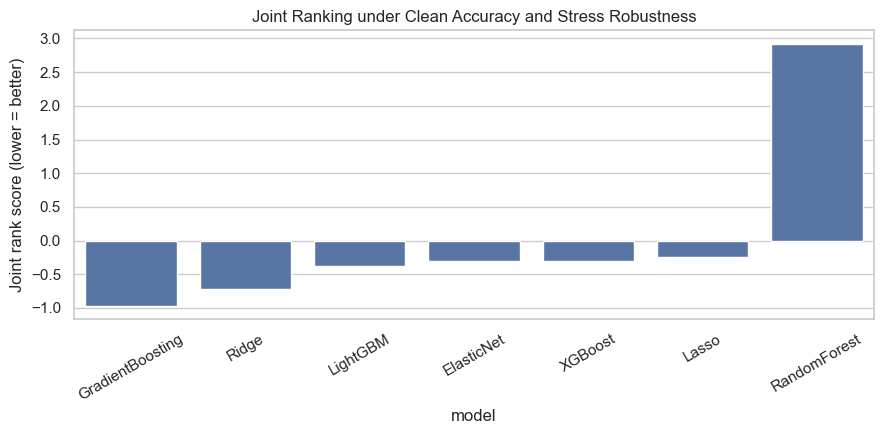

In [10]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=robust_summary, x="model", y="joint_rank_score")
plt.title("Joint Ranking under Clean Accuracy and Stress Robustness")
plt.ylabel("Joint rank score (lower = better)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "stress_benchmark_joint_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

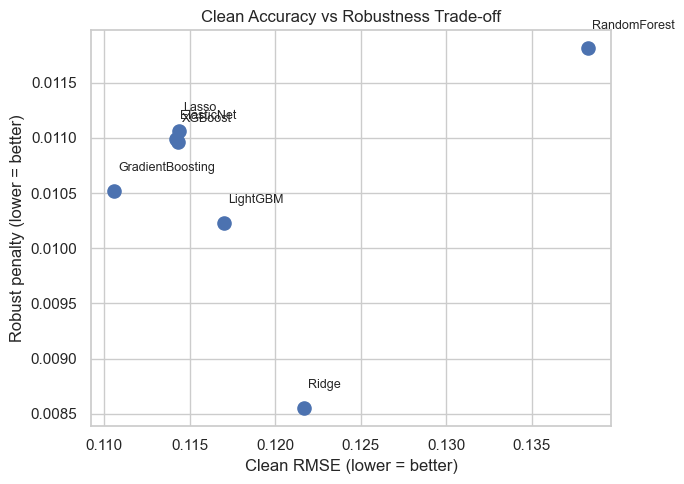

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(
    robust_summary["clean_rmse"],
    robust_summary["robust_penalty_raw"],
    s=90
)

for _, row in robust_summary.iterrows():
    plt.text(
        row["clean_rmse"] + 0.00025,
        row["robust_penalty_raw"] + 0.00018,
        row["model"],
        fontsize=9
    )

plt.xlabel("Clean RMSE (lower = better)")
plt.ylabel("Robust penalty (lower = better)")
plt.title("Clean Accuracy vs Robustness Trade-off")
plt.tight_layout()
plt.savefig(FIG_DIR / "stress_benchmark_clean_vs_robust_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation Angle

Under this revised ranking rule, **GradientBoosting becomes the champion model**.

That result is more aligned with the substantive goal of the project:

- it is the strongest model on clean prediction,
- it is still among the more stable candidates,
- and it avoids the undesirable situation where the final model is chosen mainly because it is conservative.

In short, the current conclusion is:

> **GradientBoosting is not the absolute most robust model, but it provides the best clean–robust trade-off for the housing task.**

## 7. Save the Champion Model Record

The champion from this stage will be passed to the next notebook, where I will design **targeted interventions** around its main failure modes.

In [12]:
champion_df = robust_summary.head(1).copy()
champion_model_name = champion_df.iloc[0]["model"]

champion_df.to_csv(TABLE_DIR / "stress_benchmark_champion_model.csv", index=False)

print("Champion model:", champion_model_name)
champion_df

Champion model: GradientBoosting


,rank,model,clean_rmse,clean_mae,clean_r2,feature_ablation,feature_noise,target_corruption,worst_group_rmse,best_group_rmse,mean_group_rmse,worst_group_gap,robust_penalty_raw,RobustScore,joint_rank_score
0,1,GradientBoosting,0.110588,0.074016,0.918985,0.001818,0.000015,0.000086,0.149683,0.080863,0.105893,0.039096,0.010517,-0.010517,-0.97102
